# Importar librerías

In [28]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
df = pd.read_csv("perfiles_simulados.csv")
df

,Ingreso_Mensual,Proporcion_Gasto,Gasto_Total,Nivel_Endeudamiento,Frecuencia_Ahorro,Perfil_Financiero
0,20968.73,86.58,18154.54,37.45,Media,Saludable
1,109240.09,42.20,46102.73,95.07,Baja,En Riesgo
2,65370.96,76.10,49749.30,73.20,Baja,En Riesgo
3,100837.78,78.54,79195.17,59.87,Baja,En Riesgo
4,44921.24,63.93,28718.35,15.60,Media,Saludable
...,...,...,...,...,...,...
395,105880.18,99.72,105586.83,93.08,Media,En Riesgo
396,112504.64,107.88,121369.01,85.84,Baja,En Riesgo
397,71982.88,107.51,77388.95,42.90,Baja,En Riesgo
398,86504.79,89.97,77830.22,75.09,Baja,En Riesgo


# MODELO DE PERFIL FINANCIERO

# Entrenamiento de los modelos de clasificación

Una vez finalizado el análisis exploratorio y la ingeniería de atributos, se procede al entrenamiento de los modelos de Machine Learning.

Para esta etapa se utilizarán tres algoritmos de clasificación supervisada:

- Regresión Logística
- Árbol de Decisión
- Random Forest

Cada uno presenta características distintas. La Regresión Logística requiere que las variables numéricas se encuentren escaladas, mientras que los modelos basados en árboles son capaces de trabajar directamente con los datos originales.



## Preprocesamiento mediante ColumnTransformer

Los algoritmos de Machine Learning requieren que todas las variables de entrada sean numéricas. Sin embargo, algunas variables del conjunto de datos, como **frecuencia_ahorro**, son de tipo categórico.

Para automatizar este proceso se utilizará **ColumnTransformer**, una herramienta de Scikit-Learn que permite aplicar diferentes transformaciones dependiendo del tipo de variable.

En este proyecto se realizarán las siguientes transformaciones:

- Las variables numéricas serán estandarizadas mediante **StandardScaler** para los modelos que lo requieran.
- La variable **frecuencia_ahorro** será transformada mediante **OrdinalEncoder**, respetando el orden natural de sus categorías (Baja < Media < Alta).

Al integrar estas transformaciones dentro de un **Pipeline**, se evita la fuga de información (Data Leakage) y se garantiza que el mismo procesamiento se aplique durante el entrenamiento, la validación cruzada y la predicción.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# Variables numéricas
numeric_features = [
    "Ingreso_Mensual",
    "Proporcion_Gasto",
    "Gasto_Total",
    "Nivel_Endeudamiento"
]

# Variables categóricas
categorical_features = [
    "Frecuencia_Ahorro"
]

# Preprocesador para modelos lineales
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OrdinalEncoder(
                categories=[["Baja", "Media", "Alta"]]
            ),
            categorical_features
        )
    ]
)

# Preprocesador para modelos basados en árboles
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                categories=[["Baja", "Media", "Alta"]]
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Regresión Logística

Este algoritmo requiere que las variables numéricas se encuentren en una escala similar para obtener un mejor desempeño.



## Árbol de Decisión

Los árboles de decisión generan reglas de clasificación a partir de divisiones sucesivas sobre las variables predictoras.

Debido a su naturaleza, este algoritmo no requiere que los datos se encuentren escalados.

## Random Forest

Random Forest es un método de ensamble basado en múltiples árboles de decisión.

Cada árbol es entrenado sobre una muestra diferente del conjunto de datos y el resultado final corresponde a la votación de todos ellos, lo que generalmente produce modelos más robustos y con mejor capacidad de generalización.

## Construcción de los Pipelines

Cada algoritmo utilizará un Pipeline independiente.

La Regresión Logística requiere tanto el escalamiento de las variables numéricas como la codificación de las variables categóricas.

Por otro lado, los modelos basados en árboles no necesitan escalamiento, aunque sí requieren que todas las variables sean numéricas. Por esta razón únicamente se aplica la codificación ordinal antes del entrenamiento.

In [32]:
models = {

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("classifier",
         LogisticRegression(
             max_iter=1000,
             random_state=42
         ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("classifier",
         DecisionTreeClassifier(
             random_state=42,
             max_depth=5
         ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("classifier",
         RandomForestClassifier(
             n_estimators=200,
             random_state=42
         ))
    ])

}

## Separacion de los datos de entrenamiento y prueba

In [33]:
# Variables predictoras y variable objetivo
X = df.drop(columns="Perfil_Financiero")
y = df["Perfil_Financiero"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

##Stratified KFold

Para obtener una estimación más robusta del desempeño de cada algoritmo se emplea validación cruzada estratificada de cinco particiones. En cada iteración el modelo es entrenado utilizando una combinación distinta de los datos y posteriormente evaluado sobre el subconjunto restante. Finalmente se calcula el promedio de las métricas obtenidas.

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [36]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro"
        ]
    )

    cv_results.append({
        "Modelo": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision_macro"].mean(),
        "Recall": scores["test_recall_macro"].mean(),
        "F1-Score": scores["test_f1_macro"].mean()
    })

results_cv = pd.DataFrame(cv_results)

results_cv = results_cv.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_cv

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.896875,0.908008,0.869142,0.883148
1,Decision Tree,0.831250,0.817125,0.809268,0.810341
2,Logistic Regression,0.731250,0.744444,0.699438,0.704740


Elegimos el mejor modelo de los resultados anteriores

In [37]:
best_model_name = results_cv.iloc[0]["Modelo"]

best_model = models[best_model_name]

print("El mejor modelo es:", best_model_name)

El mejor modelo es: Random Forest


Se entrena el modelo ganador utilizando los datos de Train

In [38]:
best_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OrdinalEncoder(categories=[['Baja',
                                                                              'Media',
                                                                              'Alta']]),
                                                  ['Frecuencia_Ahorro'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [39]:
y_pred = best_model.predict(X_test)

In [40]:
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

En Observación       0.83      0.87      0.85        23
     En Riesgo       0.92      0.88      0.90        41
     Saludable       0.94      1.00      0.97        16

      accuracy                           0.90        80
     macro avg       0.90      0.92      0.91        80
  weighted avg       0.90      0.90      0.90        80



## Interpretación de los resultados

El modelo seleccionado obtuvo un **Accuracy del 93%** sobre el conjunto de prueba, lo que indica que fue capaz de clasificar correctamente la mayoría de los perfiles financieros simulados que no participaron durante el entrenamiento.

Las métricas de **Precision**, **Recall** y **F1-Score** presentan valores cercanos o superiores al 0.90 para la mayoría de las clases, lo que refleja un desempeño consistente y un buen equilibrio entre la capacidad del modelo para identificar correctamente cada perfil financiero y minimizar las clasificaciones erróneas.

En conjunto, los resultados muestran que el modelo posee una adecuada capacidad de generalización sobre los datos simulados y constituye una herramienta confiable para la clasificación automática del perfil financiero.

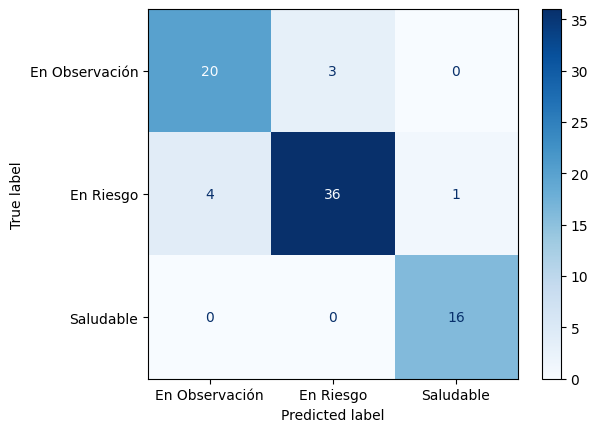

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.show()

# MODELO DE CLASIFICACIÓN DE GASTOS

In [42]:
df_gastos = pd.read_csv("dataset_gastos.csv")
df_gastos

,descripcion,categoria,monto,descripcion_limpia,longitud_descripcion,palabras_descripcion,tiene_moneda
0,COMPRA EN ELECTRODOMESTICOS,Vivienda,3193.96,compra en electrodomesticos,27,3,0
1,*combi*,Transporte,47.88,combi,7,1,0
2,COMPRA EN LIBROS,Educación,1445.34,compra en libros,16,3,0
3,COMPRA EN TEATRO,Ocio y Servicios,840.82,compra en teatro,16,3,0
4,Teatro,Ocio y Servicios,636.61,teatro,6,1,0
...,...,...,...,...,...,...,...
345,Diesel,Transporte,125.69,diesel,6,1,0
346,compra cuadernos,Educación,216.88,compra cuadernos,16,2,0
347,MATERIAL,Educación,760.84,material,8,1,0
348,compra RTP,Transporte,441.74,compra rtp,10,2,0


La variable objetivo será:

**categoria**

Mientras que como variables predictoras se utilizarán:

* descripcion_limpia
* longitud_descripcion
* palabras_descripcion
* tiene_moneda
* monto

In [43]:
X = df_gastos[
    [
        "monto",
        "descripcion_limpia",
        "longitud_descripcion",
        "palabras_descripcion",
        "tiene_moneda"
    ]
]

y = df_gastos["categoria"]

## Separacion de los datos de entrenamiento y prueba

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

## Preprocesamiento mediante ColumnTransformer

El conjunto de datos contiene tanto información textual como variables numéricas, por lo que es necesario aplicar un tratamiento diferente a cada tipo de dato antes del entrenamiento de los modelos.



Se realizan las siguientes transformaciones:

- La variable **descripcion_limpia** se convierte en una representación numérica mediante **TF-IDF (Term Frequency - Inverse Document Frequency)**, técnica ampliamente utilizada en Procesamiento de Lenguaje Natural (NLP) para cuantificar la importancia de las palabras presentes en cada descripción de gasto.
- Las variables **longitud_descripcion**, **palabras_descripcion** y **tiene_moneda** corresponden a características numéricas previamente generadas durante la ingeniería de atributos, por lo que se incorporan directamente al modelo mediante la opción `passthrough`, sin requerir transformaciones adicionales.

Este preprocesamiento se integra posteriormente dentro de un **Pipeline**, lo que garantiza que todas las transformaciones se aprendan únicamente a partir del conjunto de entrenamiento durante la validación cruzada y el entrenamiento final. De esta forma se evita la fuga de información (*Data Leakage*) y se asegura que el mismo proceso sea aplicado de manera consistente a nuevos datos durante la etapa de predicción.

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "texto",
            TfidfVectorizer(),
            "descripcion_limpia"
        ),
        (
            "numericas",
            "passthrough",
            [
                "monto",
                "longitud_descripcion",
                "palabras_descripcion",
                "tiene_moneda"
            ]
        )
    ]
)

## Construcción de los modelos de clasificación

Una vez definido el preprocesamiento, se construyen los modelos de clasificación utilizando **Pipelines** de Scikit-Learn.
Para este proyecto se evaluarán dos algoritmos ampliamente utilizados en tareas de clasificación de texto:

- **Naive Bayes (MultinomialNB):** es uno de los algoritmos más empleados en Procesamiento de Lenguaje Natural (NLP). Se basa en el Teorema de Bayes y asume independencia entre las palabras de una descripción. Su bajo costo computacional y buen desempeño sobre representaciones TF-IDF lo convierten en un excelente punto de partida para la clasificación de textos cortos, como las descripciones de transacciones financieras.

- **Regresión Logística:** es un modelo lineal supervisado que estima la probabilidad de pertenencia a cada categoría mediante una función logística. A diferencia de Naive Bayes, no asume independencia entre las características y suele ofrecer un mejor desempeño cuando existen relaciones más complejas entre las palabras y las variables adicionales generadas durante la ingeniería de atributos.

La comparación entre ambos modelos permitirá seleccionar el algoritmo con mayor capacidad para clasificar automáticamente la categoría financiera de cada gasto.

In [46]:
from sklearn.naive_bayes import MultinomialNB

models = {

    "Naive Bayes":

    Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", MultinomialNB())
    ]),

    "Regresión Logística":

    Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",
         LogisticRegression(
             max_iter=1000,
             random_state=42
         ))
    ])

}

## Stratified KFold

In [47]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [48]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro"
        ]
    )

    cv_results.append({
        "Modelo": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision_macro"].mean(),
        "Recall": scores["test_recall_macro"].mean(),
        "F1-Score": scores["test_f1_macro"].mean()
    })

results_cv = pd.DataFrame(cv_results)

results_cv = results_cv.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_cv

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.753571,0.765427,0.746047,0.743196
1,Naive Bayes,0.450000,0.452447,0.451267,0.431611


## Selección del mejor modelo

In [49]:
best_model_name = results_cv.iloc[0]["Modelo"]

best_model = models[best_model_name]

print("El mejor modelo es:", best_model_name)

El mejor modelo es: Regresión Logística


## Entrenamiento

In [50]:
best_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('texto', TfidfVectorizer(),
                                                  'descripcion_limpia'),
                                                 ('numericas', 'passthrough',
                                                  ['monto',
                                                   'longitud_descripcion',
                                                   'palabras_descripcion',
                                                   'tiene_moneda'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

##Prueba

In [51]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

    Alimentación       0.77      0.77      0.77        13
       Educación       0.62      0.56      0.59         9
Ocio y Servicios       0.78      0.54      0.64        13
           Salud       0.62      0.73      0.67        11
      Transporte       0.62      0.83      0.71        12
        Vivienda       0.91      0.83      0.87        12

        accuracy                           0.71        70
       macro avg       0.72      0.71      0.71        70
    weighted avg       0.73      0.71      0.71        70



## Interpretación de los resultados

Tras comparar los modelos candidatos mediante validación cruzada, la **Regresión Logística** fue seleccionada como el algoritmo con mejor desempeño para la clasificación automática de gastos. Posteriormente, el modelo fue evaluado utilizando el conjunto de prueba, obteniendo un **Accuracy del 71%**, lo que indica que aproximadamente siete de cada diez transacciones fueron clasificadas correctamente.

Las métricas de **Precision**, **Recall** y **F1-Score** muestran un comportamiento equilibrado entre las distintas categorías, aunque con diferencias derivadas de la complejidad del problema. La categoría **Vivienda** presentó el mejor desempeño, alcanzando un F1-Score de **0.87**, lo que sugiere que las descripciones asociadas a este tipo de gasto contienen términos distintivos que facilitan su identificación por parte del modelo.

Por otro lado, las categorías **Educación** y **Ocio y Servicios** obtuvieron los valores más bajos de F1-Score (0.59 y 0.64, respectivamente). Este comportamiento puede atribuirse a que algunas descripciones de transacciones contienen palabras o expresiones similares a las utilizadas en otras categorías, generando cierta ambigüedad durante la clasificación.

Asimismo, la categoría **Transporte** alcanzó un Recall de **0.83**, indicando que el modelo identifica correctamente la mayoría de las transacciones pertenecientes a esta clase, aunque con una precisión ligeramente menor debido a la existencia de algunos falsos positivos.

En términos generales, el modelo logró un desempeño consistente entre las diferentes categorías, alcanzando un **F1-Score macro de 0.71**, lo que indica un equilibrio adecuado en la capacidad de clasificación sin favorecer de manera significativa a alguna clase en particular.

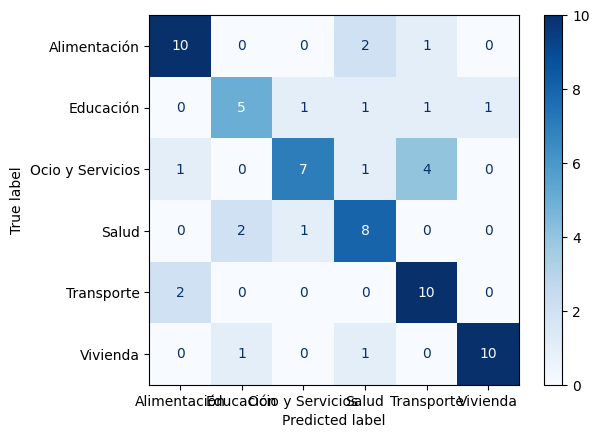

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.show()